# Adaptación del índice de Nesterov con datos Open-Meteo

## 1. Objetivo

Calcular y auditar a nivel departamento–día una adaptación del índice de Nesterov, agregarla a departamento–semana y estudiar su relación descriptiva con los tres perfiles meteorológicos y con `presencia_firms`. Nesterov no entra al clustering y no es el target supervisado.

## 2. Fuente metodológica y alcance

Fuente oficial consultada el **26/09/2026**: [INUMET — Índice de riesgo de incendio forestal](https://www.inumet.gub.uy/tiempo/indice-de-riesgo-forestal). INUMET publica `G = Σ(dᵢ·tᵢ)` y `d = E·(1-H/100)`, con temperatura y déficit de saturación medidos diariamente a las 13 h del día anterior y precipitación acumulada entre las 7 h anteriores y las 7 h del día en curso.

Este proyecto dispone de agregados diarios espaciales de Open-Meteo, no de la observación INUMET exacta de las 13 h. Se utiliza temperatura máxima diaria media espacial, humedad mínima diaria media espacial y precipitación diaria media espacial. Para obtener `E` se adopta la aproximación de Magnus `6.112·exp(17.67·T/(T+243.5))` en hPa; esa ecuación computacional no aparece desarrollada en la página de INUMET. Por estas diferencias, el resultado se denomina **adaptación o proxy de Nesterov con Open-Meteo**, no índice oficial de INUMET.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr

RUTA_DIARIA = Path("data/processed/open_meteo_department_daily/open_meteo_department_daily_2017_2025.parquet")
RUTA_SEMANAL_FIRMS = Path("data/processed/firms_open_meteo_weekly/open_meteo_firms_weekly_target_available.parquet")
RUTA_MODELO = Path("data/processed/modelado/dataset_modelado_presencia_firms.parquet")
RUTA_SALIDA = Path("data/processed/nesterov/nesterov_departamento_semana_open_meteo_2018_2025.parquet")
T = "temperature_2m_max_mean_spatial"
H = "relative_humidity_2m_min_mean_spatial"
P = "precipitation_sum_mean_spatial"
datos_diarios = pd.read_parquet(RUTA_DIARIA)
datos_diarios["fecha"] = pd.to_datetime(datos_diarios["fecha"], errors="raise")

## 3. Auditoría diaria

In [2]:
columnas_requeridas = ["departamento", "fecha", T, H, P]
assert set(columnas_requeridas).issubset(datos_diarios.columns)
assert not datos_diarios.duplicated(["departamento", "fecha"]).any()
assert datos_diarios[columnas_requeridas].notna().all().all()
assert datos_diarios[T].between(-60, 60).all()
assert datos_diarios[H].between(0, 100).all()
assert datos_diarios[P].ge(0).all()
ordenados = datos_diarios.sort_values(["departamento", "fecha"]).copy()
saltos = ordenados.groupby("departamento")["fecha"].diff().dt.days.dropna()
assert saltos.eq(1).all(), "Hay discontinuidades diarias"
auditoria = pd.Series({
    "filas": len(ordenados), "departamentos": ordenados["departamento"].nunique(),
    "fecha_min": ordenados["fecha"].min(), "fecha_max": ordenados["fecha"].max(),
    "duplicados": ordenados.duplicated(["departamento", "fecha"]).sum(),
    "nulos_variables": ordenados[[T, H, P]].isna().sum().sum(), "saltos_no_diarios": saltos.ne(1).sum(),
})
display(auditoria.to_frame("valor"))
display(ordenados[[T, H, P]].describe().T)

,valor
filas,62434
departamentos,19
fecha_min,2017-01-02 00:00:00
fecha_max,2025-12-31 00:00:00
duplicados,0
nulos_variables,0
saltos_no_diarios,0


,count,mean,std,min,25%,50%,75%,max
temperature_2m_max_mean_spatial,62434.0,22.129333,6.058033,5.64,17.460000,22.2700,26.545455,39.650000
relative_humidity_2m_min_mean_spatial,62434.0,55.323694,13.864239,15.40,45.938419,54.9375,64.631579,97.222222
precipitation_sum_mean_spatial,62434.0,3.028927,8.137039,0.00,0.000000,0.0000,1.230000,135.900000


## 4. Fórmula diaria y reglas de precipitación

La contribución diaria es `d·t`. Sobre el acumulado anterior se aplican las reglas oficiales publicadas:

- lluvia ≤ 2,0 mm: no reducir;
- 2,1–5,0 mm: conservar 75% de `G` anterior y sumar `d·t`;
- 5,1–8,0 mm: conservar 50% y sumar `d·t`;
- 8,1–10,0 mm: abandonar la suma anterior y usar `G=d·t`;
- >10,0 mm: `G=0`; el cálculo recomienza después.

Open-Meteo puede producir decimales entre las décimas publicadas. Operativamente se usan los cortes continuos `>2`, `>5`, `>8` y `>10`, sin dejar observaciones sin regla. El primer día disponible de cada departamento comienza con `G anterior=0`. Se incluye 2017 como período de calentamiento antes del target 2018–2025.

In [3]:
def calcular_nesterov(grupo):
    grupo = grupo.sort_values("fecha").copy()
    presion_saturacion_hpa = 6.112 * np.exp((17.67 * grupo[T]) / (grupo[T] + 243.5))
    grupo["deficit_saturacion_hpa"] = presion_saturacion_hpa * (1 - grupo[H] / 100)
    grupo["contribucion_nesterov"] = grupo["deficit_saturacion_hpa"] * grupo[T]
    acumulado = 0.0
    valores = []
    reglas = []
    for lluvia, contribucion in zip(grupo[P], grupo["contribucion_nesterov"]):
        if lluvia <= 2.0:
            acumulado = acumulado + contribucion; regla = "Sin reducción"
        elif lluvia <= 5.0:
            acumulado = 0.75 * acumulado + contribucion; regla = "Reduce 25%"
        elif lluvia <= 8.0:
            acumulado = 0.50 * acumulado + contribucion; regla = "Reduce 50%"
        elif lluvia <= 10.0:
            acumulado = contribucion; regla = "Reinicio con contribución del día"
        else:
            acumulado = 0.0; regla = "Interrupción por lluvia >10 mm"
        valores.append(max(0.0, acumulado)); reglas.append(regla)
    grupo["nesterov_open_meteo_diario"] = valores
    grupo["regla_precipitacion"] = reglas
    return grupo

nesterov_diario = pd.concat(
    [calcular_nesterov(grupo) for _, grupo in ordenados.groupby("departamento")],
    ignore_index=True,
)
assert nesterov_diario["nesterov_open_meteo_diario"].ge(0).all()
display(nesterov_diario[["departamento", "fecha", T, H, P, "deficit_saturacion_hpa", "contribucion_nesterov", "regla_precipitacion", "nesterov_open_meteo_diario"]].head(10))

,departamento,fecha,temperature_2m_max_mean_spatial,relative_humidity_2m_min_mean_spatial,precipitation_sum_mean_spatial,deficit_saturacion_hpa,contribucion_nesterov,regla_precipitacion,nesterov_open_meteo_diario
0,Artigas,2017-01-02,31.942857,57.500000,0.728571,20.161236,644.007474,Sin reducción,644.007474
1,Artigas,2017-01-03,33.400000,56.000000,0.464286,22.661092,756.880475,Sin reducción,1400.887949
2,Artigas,2017-01-04,29.200000,63.571429,1.492857,14.768469,431.239309,Sin reducción,1832.127258
3,Artigas,2017-01-05,28.928571,65.000000,7.192857,13.968001,404.074329,Reduce 50%,1320.137958
4,Artigas,2017-01-06,29.457143,53.785714,0.000000,19.016250,560.164380,Sin reducción,1880.302338
5,Artigas,2017-01-07,30.200000,57.714286,0.285714,18.160288,548.440695,Sin reducción,2428.743033
6,Artigas,2017-01-08,27.564286,74.714286,6.250000,9.320069,256.901038,Reduce 50%,1471.272555
7,Artigas,2017-01-09,32.800000,60.285714,18.021429,19.775184,648.626048,Interrupción por lluvia >10 mm,0.000000
8,Artigas,2017-01-10,28.135714,65.071429,33.128571,13.311486,374.528164,Interrupción por lluvia >10 mm,0.000000
9,Artigas,2017-01-11,29.914286,51.642857,0.092857,20.429386,611.130496,Sin reducción,611.130496


## 5. Pruebas manuales de acumulación y reinicio

In [4]:
def aplicar_reglas_manual(lluvias, contribuciones):
    previo = 0.0; salida = []
    for lluvia, aporte in zip(lluvias, contribuciones):
        if lluvia <= 2: actual = previo + aporte
        elif lluvia <= 5: actual = .75 * previo + aporte
        elif lluvia <= 8: actual = .50 * previo + aporte
        elif lluvia <= 10: actual = aporte
        else: actual = 0.0
        salida.append(actual); previo = actual
    return salida
caso = aplicar_reglas_manual([0, 3, 6, 9, 11, 0], [100] * 6)
esperado = [100, 175, 187.5, 100, 0, 100]
assert np.allclose(caso, esperado)
assert aplicar_reglas_manual([11, 12, 0], [100, 100, 100]) == [0, 0, 100]
display(pd.DataFrame({"lluvia_mm": [0, 3, 6, 9, 11, 0], "contribución": 100, "G_obtenido": caso, "G_esperado": esperado}))

,lluvia_mm,contribución,G_obtenido,G_esperado
0,0,100,100.0,100.0
1,3,100,175.0,175.0
2,6,100,187.5,187.5
3,9,100,100.0,100.0
4,11,100,0.0,0.0
5,0,100,100.0,100.0


## 6. Agregación departamento–semana

Se conservan el valor al cierre del domingo y el máximo semanal. Se adopta **el máximo semanal** para la escala de riesgo porque captura el mayor peligro meteorológico alcanzado antes de un posible reinicio por lluvia; el cierre sigue disponible para trazabilidad. La media no se utiliza porque suavizaría un estado acumulativo.

In [5]:
nesterov_diario["fecha_inicio_semana"] = nesterov_diario["fecha"] - pd.to_timedelta(nesterov_diario["fecha"].dt.weekday, unit="D")
nesterov_semanal = nesterov_diario.groupby(["departamento", "fecha_inicio_semana"]).agg(
    n_dias=("fecha", "size"),
    nesterov_cierre_semana=("nesterov_open_meteo_diario", "last"),
    nesterov_max_semanal=("nesterov_open_meteo_diario", "max"),
).reset_index()
nesterov_semanal = nesterov_semanal.loc[nesterov_semanal["n_dias"].eq(7) & nesterov_semanal["fecha_inicio_semana"].between("2018-01-01", "2025-12-22")].copy()
assert len(nesterov_semanal) == 7923
assert not nesterov_semanal.duplicated(["departamento", "fecha_inicio_semana"]).any()
display(nesterov_semanal[["nesterov_cierre_semana", "nesterov_max_semanal"]].describe())

,nesterov_cierre_semana,nesterov_max_semanal
count,7923.000000,7923.000000
mean,2283.330654,3739.829174
std,3189.467642,4085.387109
min,0.000000,0.000000
25%,388.661484,1294.504378
50%,1221.305033,2362.766105
75%,2760.173754,4566.469094
max,38979.338100,41992.754009


## 7. Grados de riesgo publicados

INUMET publica: 301–500 `Riesgo bajo`; 501–1000 `Riesgo medio`; 1001–4000 `Riesgo alto`; y >4000 `Riesgo muy alto`. No publica una categoría para valores inferiores a 301. Como el proxy es continuo, los pequeños intervalos 500–501 y 1000–1001 tampoco están cubiertos literalmente por la tabla. Se mantienen explícitamente como `Fuera de intervalos publicados`; no se inventan categorías ni se redondea el índice.

In [6]:
G = nesterov_semanal["nesterov_max_semanal"]
condiciones = [G.lt(301), G.between(301, 500, inclusive="both"), G.between(501, 1000, inclusive="both"), G.between(1001, 4000, inclusive="both"), G.gt(4000)]
niveles = ["Sin grado publicado (G < 301)", "Riesgo bajo", "Riesgo medio", "Riesgo alto", "Riesgo muy alto"]
nesterov_semanal["nivel_riesgo_nesterov"] = pd.Categorical(
    np.select(condiciones, niveles, default="Fuera de intervalos publicados"),
    categories=["Sin grado publicado (G < 301)", "Fuera de intervalos publicados", "Riesgo bajo", "Riesgo medio", "Riesgo alto", "Riesgo muy alto"], ordered=False)
distribucion_niveles = nesterov_semanal["nivel_riesgo_nesterov"].value_counts(sort=False).to_frame("departamento_semanas")
distribucion_niveles["porcentaje"] = distribucion_niveles["departamento_semanas"] / len(nesterov_semanal) * 100
display(distribucion_niveles.round(3))

,departamento_semanas,porcentaje
nivel_riesgo_nesterov,,
Sin grado publicado (G < 301),80,1.010
Fuera de intervalos publicados,6,0.076
Riesgo bajo,286,3.610
Riesgo medio,1013,12.786
Riesgo alto,4198,52.985
Riesgo muy alto,2340,29.534


## 8. Validación y exportación del artefacto derivadoEste archivo queda separado del dataset supervisado y no se incorpora automáticamente a `X`.

In [7]:
salida = nesterov_semanal[["departamento", "fecha_inicio_semana", "nesterov_cierre_semana", "nesterov_max_semanal", "nivel_riesgo_nesterov"]].copy()
salida["metodologia_nesterov"] = "Adaptación Open-Meteo de metodología publicada por INUMET; no oficial"
assert salida.shape == (7923, 6)
assert salida.notna().all().all()
RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)
salida.to_parquet(RUTA_SALIDA, index=False)
print("Guardado:", RUTA_SALIDA, salida.shape)

Guardado: data/processed/nesterov/nesterov_departamento_semana_open_meteo_2018_2025.parquet (7923, 6)


## 9. Relación descriptiva con FIRMS

In [8]:
firms = pd.read_parquet(RUTA_SEMANAL_FIRMS)
firms["fecha_inicio_semana"] = pd.to_datetime(firms["fecha_inicio_semana"], errors="raise")
firms["presencia_firms"] = firms["cantidad_detecciones"].gt(0).astype("int8")
analisis = firms.merge(salida, on=["departamento", "fecha_inicio_semana"], how="inner", validate="one_to_one")
assert len(analisis) == 7923
por_nivel = analisis.groupby("nivel_riesgo_nesterov", observed=False).agg(
    observaciones=("presencia_firms", "size"), positivas_firms=("presencia_firms", "sum"),
    porcentaje_firms_positivo=("presencia_firms", lambda s: s.mean() * 100),
    detecciones_media=("cantidad_detecciones", "mean"), detecciones_mediana=("cantidad_detecciones", "median"),
)
display(por_nivel.round(4))
tabla_chi = pd.crosstab(analisis["nivel_riesgo_nesterov"], analisis["presencia_firms"])
chi2, p_chi, _, _ = chi2_contingency(tabla_chi)
cramer_v = np.sqrt(chi2 / (len(analisis) * min(tabla_chi.shape[0] - 1, tabla_chi.shape[1] - 1)))
mann = mannwhitneyu(analisis.loc[analisis["presencia_firms"].eq(0), "nesterov_max_semanal"], analisis.loc[analisis["presencia_firms"].eq(1), "nesterov_max_semanal"], alternative="two-sided")
rho, p_spearman = spearmanr(analisis["nesterov_max_semanal"], analisis["cantidad_detecciones"])
display(pd.Series({"chi2": chi2, "p_chi2": p_chi, "cramer_v": cramer_v, "U_mann_whitney": mann.statistic, "p_mann_whitney": mann.pvalue, "spearman_rho": rho, "p_spearman": p_spearman}).to_frame("valor"))

,observaciones,positivas_firms,porcentaje_firms_positivo,detecciones_media,detecciones_mediana
nivel_riesgo_nesterov,,,,,
Sin grado publicado (G < 301),80,1,1.2500,0.0125,0.0
Fuera de intervalos publicados,6,2,33.3333,0.6667,0.0
Riesgo bajo,286,33,11.5385,0.2098,0.0
Riesgo medio,1013,212,20.9279,0.5035,0.0
Riesgo alto,4198,1737,41.3768,1.1656,0.0
Riesgo muy alto,2340,971,41.4957,1.2991,0.0


,valor
chi2,2.891753e+02
p_chi2,2.125353e-60
cramer_v,1.910451e-01
U_mann_whitney,5.971900e+06
p_mann_whitney,5.763593e-44
spearman_rho,1.545685e-01
p_spearman,1.474238e-43


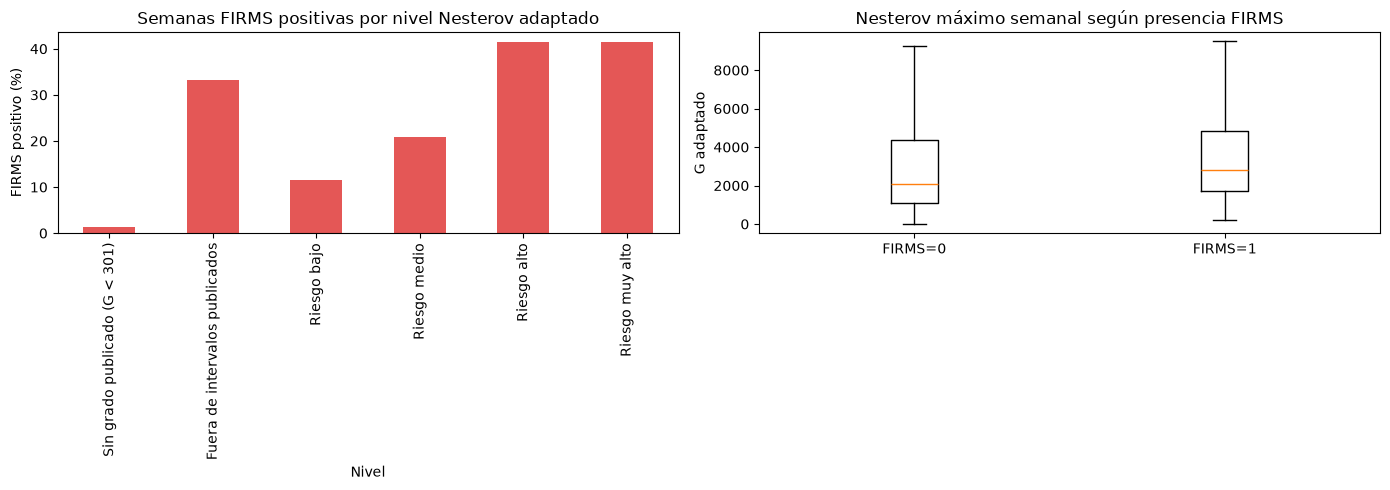

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden_niveles = list(salida["nivel_riesgo_nesterov"].cat.categories)
por_nivel.reindex(orden_niveles)["porcentaje_firms_positivo"].plot.bar(ax=axes[0], color="#e45756")
axes[0].set(title="Semanas FIRMS positivas por nivel Nesterov adaptado", xlabel="Nivel", ylabel="FIRMS positivo (%)")
axes[1].boxplot([analisis.loc[analisis["presencia_firms"].eq(valor), "nesterov_max_semanal"] for valor in [0, 1]], tick_labels=["FIRMS=0", "FIRMS=1"], showfliers=False)
axes[1].set(title="Nesterov máximo semanal según presencia FIRMS", ylabel="G adaptado")
plt.tight_layout(); plt.show()

## 10. Relación con los tres perfiles meteorológicos

,count,mean,std,min,25%,50%,75%,max
perfil_meteorologico,,,,,,,,
Cálido-seco,2365.0,7576.858,5348.334,929.612,3944.708,5920.478,9661.223,41992.754
Fresco-húmedo-lluvioso,3198.0,2031.505,1815.273,0.000,839.902,1533.265,2539.450,14025.027
Fresco-seco,2360.0,2209.596,1363.613,292.512,1249.263,1882.774,2872.167,10681.091


nivel_riesgo_nesterov,Sin grado publicado (G < 301),Fuera de intervalos publicados,Riesgo bajo,Riesgo medio,Riesgo alto,Riesgo muy alto
perfil_meteorologico,,,,,,
Cálido-seco,0.00,0.00,0.00,0.04,26.05,73.91
Fresco-húmedo-lluvioso,2.44,0.03,7.91,20.70,57.07,11.85
Fresco-seco,0.08,0.21,1.40,14.83,74.45,9.03


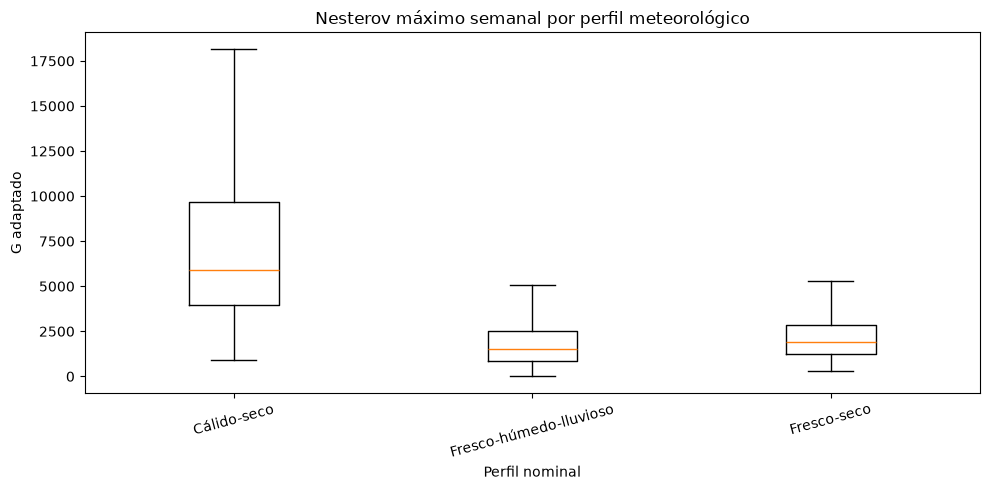

In [10]:
modelo = pd.read_parquet(RUTA_MODELO)
modelo["fecha_inicio_semana"] = pd.to_datetime(modelo["fecha_inicio_semana"], errors="raise")
assert modelo["perfil_meteorologico"].nunique() == 3
perfiles = modelo[["departamento", "fecha_inicio_semana", "perfil_meteorologico"]].merge(salida, on=["departamento", "fecha_inicio_semana"], validate="one_to_one")
resumen_perfiles = perfiles.groupby("perfil_meteorologico")["nesterov_max_semanal"].describe(percentiles=[.25, .5, .75])
niveles_perfiles = pd.crosstab(perfiles["perfil_meteorologico"], perfiles["nivel_riesgo_nesterov"], normalize="index").mul(100)
display(resumen_perfiles.round(3)); display(niveles_perfiles.round(2))
fig, ax = plt.subplots(figsize=(10, 5))
orden_perfiles = sorted(perfiles["perfil_meteorologico"].astype(str).unique())
ax.boxplot([perfiles.loc[perfiles["perfil_meteorologico"].astype(str).eq(p), "nesterov_max_semanal"] for p in orden_perfiles], tick_labels=orden_perfiles, showfliers=False)
ax.set(title="Nesterov máximo semanal por perfil meteorológico", xlabel="Perfil nominal", ylabel="G adaptado")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 11. Redundancia con meteorología

In [11]:
variables_semanales = ["temperature_2m_max_mean_weekly", "relative_humidity_2m_min_mean_weekly", "wind_speed_10m_max_mean_weekly", "precipitation_sum_weekly"]
filas_correlacion = []
for variable in variables_semanales:
    rho_variable, p_variable = spearmanr(analisis["nesterov_max_semanal"], analisis[variable])
    filas_correlacion.append({"variable": variable, "spearman_rho": rho_variable, "p_value": p_variable})
correlaciones = pd.DataFrame(filas_correlacion).sort_values("spearman_rho", key=abs, ascending=False)
display(correlaciones)

,variable,spearman_rho,p_value
0,temperature_2m_max_mean_weekly,0.740407,0.000000e+00
1,relative_humidity_2m_min_mean_weekly,-0.705485,0.000000e+00
3,precipitation_sum_weekly,-0.228881,1.097190e-94
2,wind_speed_10m_max_mean_weekly,-0.042333,1.637754e-04


Nesterov adaptado está fuertemente asociado con temperatura y humedad porque se construye directamente con ellas; también incorpora memoria diaria y reinicios por precipitación. No constituye leakage del target FIRMS, pero puede aportar poca información independiente frente a las variables meteorológicas y generar multicolinealidad. Su contribución deberá evaluarse mediante comparación de modelos en validation, no por significancia descriptiva.

## 12. Papel del índice de Nesterov en el PAA

```text
Meteorología
    │
    ├──> K-Means → perfiles meteorológicos
    │
    └──> Nesterov adaptado → indicador/nivel meteorológico de riesgo

Contexto + meteorología + perfil + Nesterov
                        ↓
              clasificación supervisada
                        ↓
              presencia FIRMS (0/1)
```

FIRMS continúa siendo el fenómeno observado y el target. Nesterov es una medida meteorológica derivada y los perfiles son un resumen no supervisado. Entrenar un modelo con temperatura, humedad y precipitación para reproducir `nivel_riesgo_nesterov` sería poco informativo: aproximaría una regla conocida construida con esas mismas variables.

## 13. Conclusión

La implementación reproduce la estructura acumulativa y las reglas de lluvia publicadas por INUMET, pero utiliza sustitutos diarios Open-Meteo en lugar de observaciones de las 13 h. Por eso es una **adaptación/proxy**, no el índice oficial. El máximo semanal es la representación principal; el cierre semanal se conserva.

El aumento del porcentaje FIRMS positivo entre niveles y las pruebas estadísticas muestran asociación descriptiva, no capacidad predictiva ni causalidad. La magnitud de Cramér's V y Spearman debe interpretarse junto con la fuerte redundancia meteorológica. El artefacto queda separado y su incorporación al dataset supervisado permanece pendiente de validación y de la estrategia de evaluación acordada.